In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('vius_2021_puf.csv')

In [6]:
year_mapping = {
    'P99': 'Pre-1999',
    '00': '2000', '01': '2001', '02': '2002', '03': '2003', '04': '2004',
    '05': '2005', '06': '2006', '07': '2007', '08': '2008', '09': '2009',
    '10': '2010', '11': '2011', '12': '2012', '13': '2013', '14': '2014',
    '15': '2015', '16': '2016', '17': '2017', '18': '2018', '19': '2019',
    '20': '2020', '21P': '2021-2022'
}

heavy_weight_codes = ['9', '10', '11', '12', '13', '14', '15']
ordered_labels = ['Pre-2010'] + [str(y) for y in range(2010, 2021)] + ['2021-2022']

states = ['IN', 'IL', 'WI', 'MI']

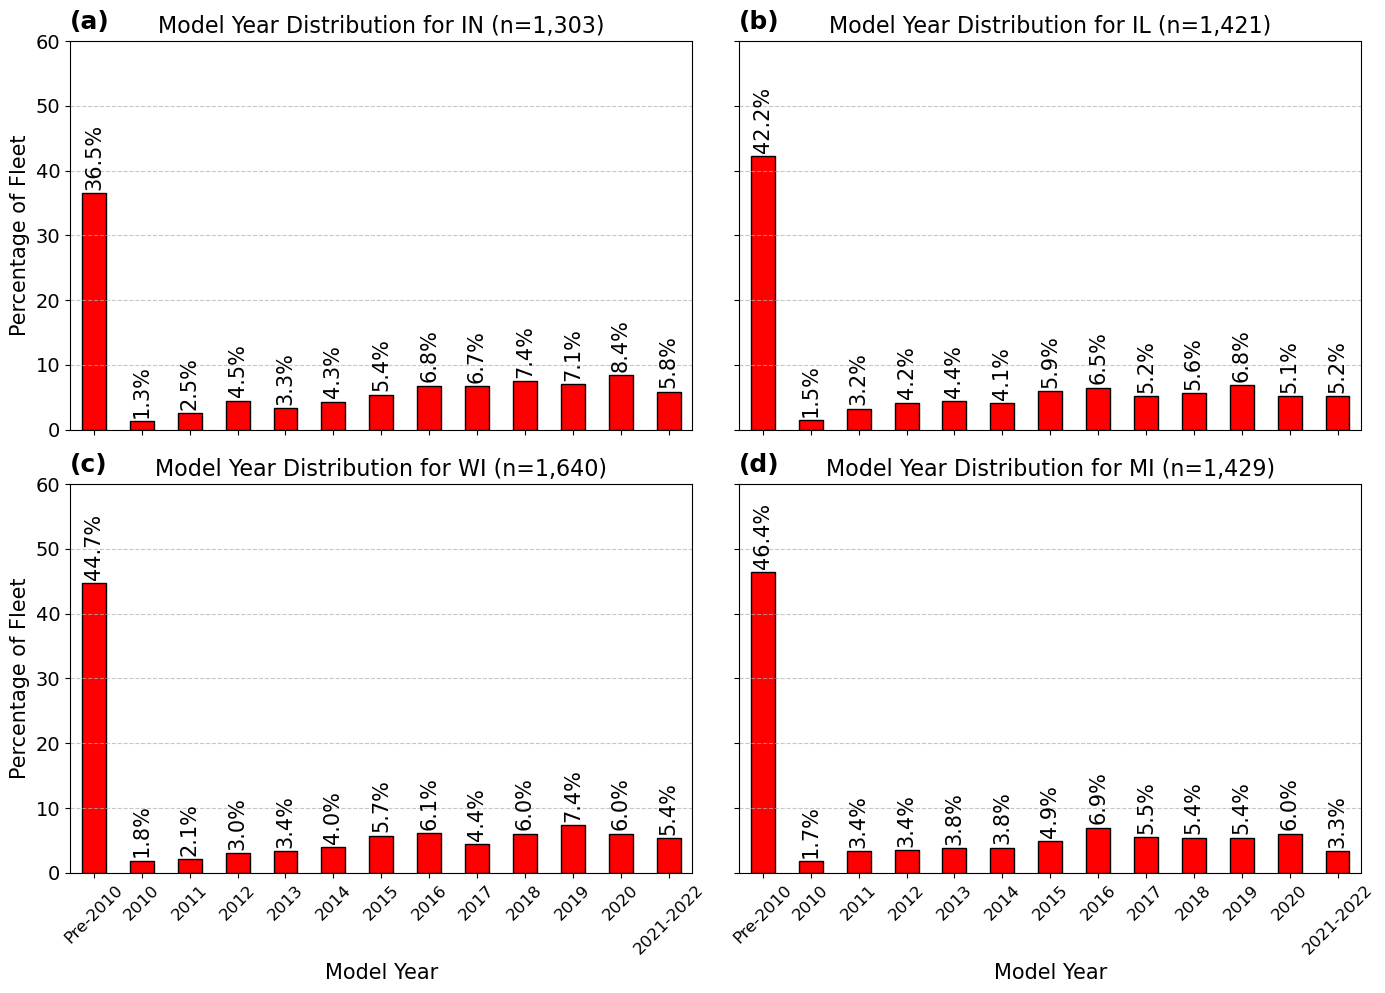

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True)
axes = axes.ravel()
# Panel labels
panel_labels = ['(a)', '(b)', '(c)', '(d)']

for i, st in enumerate(states):
    # Filter by state, drop unreported model years
    st_df = df[(df['REGSTATE'] == st) & (df['MODELYEAR'] != 'Z')].copy()
    st_df['ModelYearReadable'] = st_df['MODELYEAR'].map(year_mapping)
    st_df = st_df[st_df['ModelYearReadable'].notna()]
    
    # Group model years (Pre-2010, individual 2010–2020, 2021–2022)
    grouped_years = []
    for val in st_df['ModelYearReadable']:
        if val in ['Pre-1999'] + [str(y) for y in range(2000, 2010)]:
            grouped_years.append('Pre-2010')
        elif val in [str(y) for y in range(2010, 2021)]:
            grouped_years.append(val)
        elif val == '2021-2022':
            grouped_years.append('2021-2022')
        else:
            grouped_years.append('Unknown')
    st_df['ModelYearGrouped'] = grouped_years
    
    # Counts and percentages
    counts = st_df['ModelYearGrouped'].value_counts()
    counts = counts.reindex(ordered_labels, fill_value=0)
    total_n = int(counts.sum())
    percentages = (counts / total_n * 100) if total_n > 0 else counts.astype(float)
    
    # Plot
    ax = axes[i]
    percentages.plot(kind='bar', ax=ax, color='red', edgecolor='black')
    ax.set_xlabel('Model Year', fontsize=15)
    ax.set_ylabel('Percentage of Fleet', fontsize=15)
    ax.set_title(
        f'Model Year Distribution for '
        f'{st} (n={total_n:,})',
        fontsize=16
    )
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 60)
    
    ax.text(
    0., 1.08, panel_labels[i],
    transform=ax.transAxes,
    fontsize=18,
    fontweight='bold',
    va='top',
    ha='left'
)
    # Annotate bars
    for j, val in enumerate(percentages.values):
        if pd.notna(val):
            ax.text(j, val+1.15, f'{val:.1f}%', ha='center', fontsize=15, rotation=90)


plt.tight_layout()
plt.show()